# Notebook 4 — Comparison: Nelson-Siegel vs VAE

This notebook performs the key comparison of the paper:
1. **In-sample RMSE distributions** (Fig. 9, 10, 11)
2. **Out-of-sample analysis** (Fig. 12) — train/test split
3. **Per-currency breakdown**
4. **Historical vs reconstructed curves** (Fig. 14)
5. **Statistical significance tests**

## 0 - Imports

In [10]:
from typing import NamedTuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Dict, Optional, Tuple, List

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Path("figs").mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1 - Configuration & Data

In [12]:
class NSResult(NamedTuple):
    beta: np.ndarray
    lam: float
    lam2: float
    fitted: np.ndarray
    residuals: np.ndarray
    rmse: float

In [13]:
with open("clean_swap_data.pkl", "rb") as f:
    data = pickle.load(f)
with open("ns_results.pkl", "rb") as f:
    ns_data = pickle.load(f)
with open("vae_results.pkl", "rb") as f:
    vae_data = pickle.load(f)

In [14]:
swap_data: Dict[str, pd.DataFrame] = data["swap_data"]          # full history per ccy
swap_aligned: Dict[str, pd.DataFrame] = data["swap_aligned"]    # common dates across ccy
TARGET_TENORS = data["target_tenors"]

ns_results = ns_data["ns_results"]    # dict[ccy] -> list of NSResult (rmse in bp)
nss_results = ns_data["nss_results"]  # dict[ccy] -> list of NSResult (rmse in bp)
#ens results

rmse_vae: Dict[str, np.ndarray] = vae_data["rmse_results"]      # dict like "MultiVAE_GBP" -> rmse(bp)
cfg = vae_data["config"]

S_MIN, S_MAX = float(cfg["S_MIN"]), float(cfg["S_MAX"])
BP_PER_UNIT = float(cfg.get("bp_per_unit", 10000.0))

## 2 - Build clean RMSE structures (all in bp)

In [17]:
rmse_ns: Dict[str, np.ndarray] = {}
rmse_nss: Dict[str, np.ndarray] = {}

for ccy in CURRENCIES:
    if ccy in ns_results:
        rmse_ns[ccy] = np.array([r.rmse for r in ns_results[ccy]], dtype=float)
    if ccy in nss_results:
        rmse_nss[ccy] = np.array([r.rmse for r in nss_results[ccy]], dtype=float)

In [18]:
def concat_rmse(prefix: str) -> np.ndarray:
    chunks = []
    for ccy in CURRENCIES:
        key = f"{prefix}_{ccy}"
        if key in rmse_vae:
            chunks.append(np.asarray(rmse_vae[key], dtype=float))
    return np.concatenate(chunks) if len(chunks) else np.array([])

all_ns  = np.concatenate([rmse_ns[c] for c in CURRENCIES if c in rmse_ns]) if rmse_ns else np.array([])
all_nss = np.concatenate([rmse_nss[c] for c in CURRENCIES if c in rmse_nss]) if rmse_nss else np.array([])
all_single = concat_rmse("SingleVAE")
all_multi  = concat_rmse("MultiVAE")
all_cvae   = concat_rmse("CVAE")

In [19]:
rows = []
def add_row(ccy: str, method: str, arr: np.ndarray):
    if arr is None or len(arr) == 0:
        return
    rows.append({
        "Currency": ccy,
        "Method": method,
        "N": len(arr),
        "Mean(bp)": float(np.mean(arr)),
        "Median(bp)": float(np.median(arr)),
        "Std(bp)": float(np.std(arr)),
        "P95(bp)": float(np.percentile(arr, 95)),
        "Max(bp)": float(np.max(arr)),
    })

In [20]:
for ccy in CURRENCIES:
    add_row(ccy, "NS (3D)", rmse_ns.get(ccy, np.array([])))
    add_row(ccy, "NSS (4D)", rmse_nss.get(ccy, np.array([])))
    add_row(ccy, "Single VAE (2D)", np.asarray(rmse_vae.get(f"SingleVAE_{ccy}", np.array([]))))
    add_row(ccy, "Multi VAE (2D)",  np.asarray(rmse_vae.get(f"MultiVAE_{ccy}", np.array([]))))
    add_row(ccy, "CVAE (2D)",       np.asarray(rmse_vae.get(f"CVAE_{ccy}", np.array([]))))

df_comparison = pd.DataFrame(rows).sort_values(["Currency", "Method"])
print("\n RMSE comparison (bp):")
print(df_comparison.to_string(index=False))


 RMSE comparison (bp):
Currency          Method   N  Mean(bp)  Median(bp)   Std(bp)   P95(bp)    Max(bp)
     EUR       CVAE (2D) 712  3.000820    2.711447  1.409740  5.722712  10.751091
     EUR  Multi VAE (2D) 712 19.274792   19.237289  6.875974 30.605772  39.472454
     EUR         NS (3D) 712  6.689811    6.805846  1.742249  9.125237  11.690745
     EUR        NSS (4D) 712  1.013690    0.826726  0.798777  2.214983   8.970877
     EUR Single VAE (2D) 757 36.597183   36.605213 14.414931 64.547386  79.353264
     GBP       CVAE (2D) 712  2.605778    2.373651  1.183278  5.053274   8.112665
     GBP  Multi VAE (2D) 712 25.065342   22.093788 16.174318 49.977283  58.479580
     GBP         NS (3D) 712  2.541196    2.460830  0.315150  3.168763   4.459007
     GBP        NSS (4D) 712  0.441395    0.355659  0.292429  0.947560   2.561159
     GBP Single VAE (2D) 753 36.856289   36.188240 20.275595 75.975409 115.624275
     JPY       CVAE (2D) 712  2.782471    2.587107  1.499232  5.275199  14

## 3 - In-sample RMSE distributions

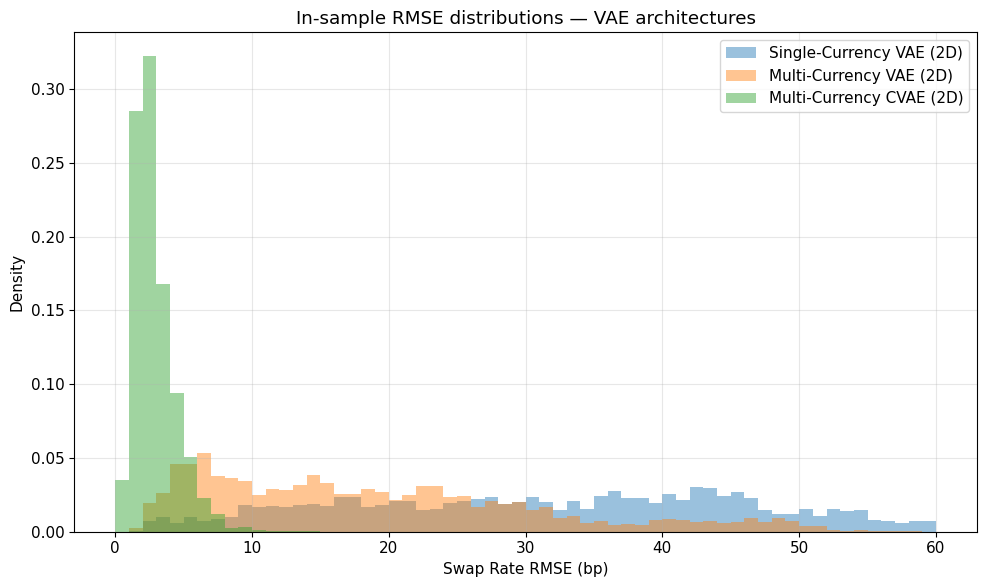

In [21]:
# compare VAE architectures (all currencies pooled)
fig, ax = plt.subplots(figsize=(10, 6))

for label, arr in [
    ("Single-Currency VAE (2D)", all_single),
    ("Multi-Currency VAE (2D)", all_multi),
    ("Multi-Currency CVAE (2D)", all_cvae),
]:
    if len(arr):
        ax.hist(arr, bins=60, alpha=0.45, density=True, label=label, range=(0, 60))

ax.set_xlabel("Swap Rate RMSE (bp)")
ax.set_ylabel("Density")
ax.set_title("In-sample RMSE distributions — VAE architectures")
ax.legend()
plt.tight_layout()
plt.savefig("figs/fig_11_vae_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

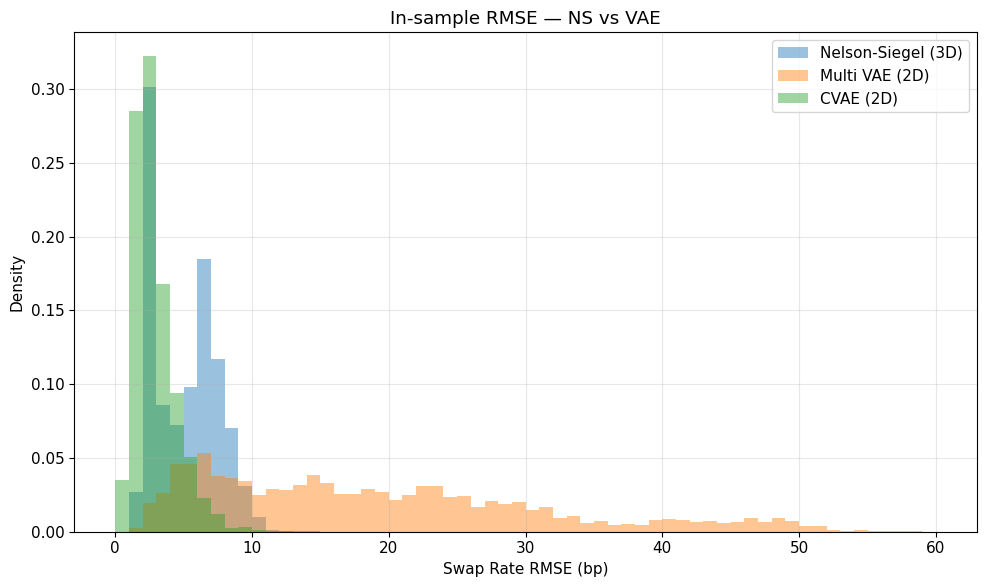

In [22]:
# NS vs Multi-VAE vs CVAE (all currencies pooled)
fig, ax = plt.subplots(figsize=(10, 6))

if len(all_ns):
    ax.hist(all_ns, bins=60, alpha=0.45, density=True, label="Nelson-Siegel (3D)", range=(0, 60))
if len(all_multi):
    ax.hist(all_multi, bins=60, alpha=0.45, density=True, label="Multi VAE (2D)", range=(0, 60))
if len(all_cvae):
    ax.hist(all_cvae, bins=60, alpha=0.45, density=True, label="CVAE (2D)", range=(0, 60))

ax.set_xlabel("Swap Rate RMSE (bp)")
ax.set_ylabel("Density")
ax.set_title("In-sample RMSE — NS vs VAE")
ax.legend()
plt.tight_layout()
plt.savefig("figs/fig_12_ns_vs_vae.png", dpi=150, bbox_inches="tight")
plt.show()

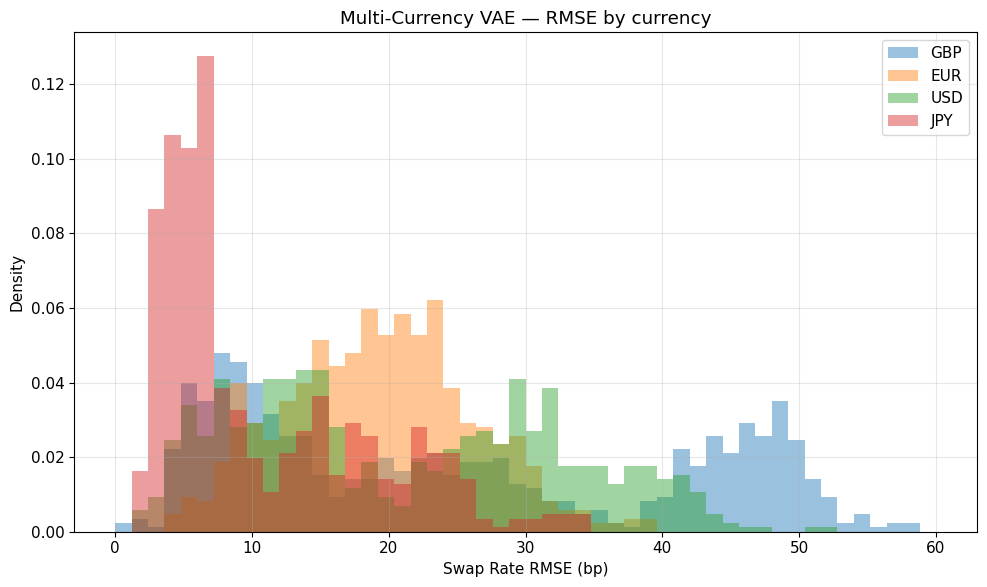

In [23]:
# Multi-VAE RMSE by currency
fig, ax = plt.subplots(figsize=(10, 6))
for ccy in CURRENCIES:
    key = f"MultiVAE_{ccy}"
    if key in rmse_vae:
        ax.hist(np.asarray(rmse_vae[key]), bins=50, alpha=0.45, density=True, label=ccy, range=(0, 60))

ax.set_xlabel("Swap Rate RMSE (bp)")
ax.set_ylabel("Density")
ax.set_title("Multi-Currency VAE — RMSE by currency")
ax.legend()
plt.tight_layout()
plt.savefig("figs/fig_13_rmse_by_ccy.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 - Reload Multi-VAE model to reconstruct curves

In [24]:
class VAE(nn.Module):
    def __init__(self, input_dim=7, latent_dim=2, hidden_dim=4, multi_currency=False):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        if not multi_currency:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, 2 * latent_dim))
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, input_dim), nn.Sigmoid())
        else:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, input_dim), nn.Tanh(),
                nn.Linear(input_dim, 2 * latent_dim))
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, input_dim), nn.Tanh(),
                nn.Linear(input_dim, input_dim), nn.Sigmoid())

    def encode(self, x):
        h = self.encoder(x)
        return h[:, :self.latent_dim], h[:, self.latent_dim:]

    def forward(self, x):
        mu, logvar = self.encode(x)
        # deterministic recon for plotting
        z = mu
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
multi_vae = VAE(7, 2, 4, multi_currency=True).to(device)
state = torch.load("multi_vae_weights.pt", map_location=device)
multi_vae.load_state_dict(state)
multi_vae.eval()
print("\n Multi-currency VAE loaded for recon plots on:", device)


 Multi-currency VAE loaded for recon plots on: cpu


In [28]:
def normalize_rates(r: np.ndarray) -> np.ndarray:
    x = (r - S_MIN) / (S_MAX - S_MIN)
    return np.clip(x, 0.0, 1.0)

def denormalize_rates(x: np.ndarray) -> np.ndarray:
    return x * (S_MAX - S_MIN) + S_MIN

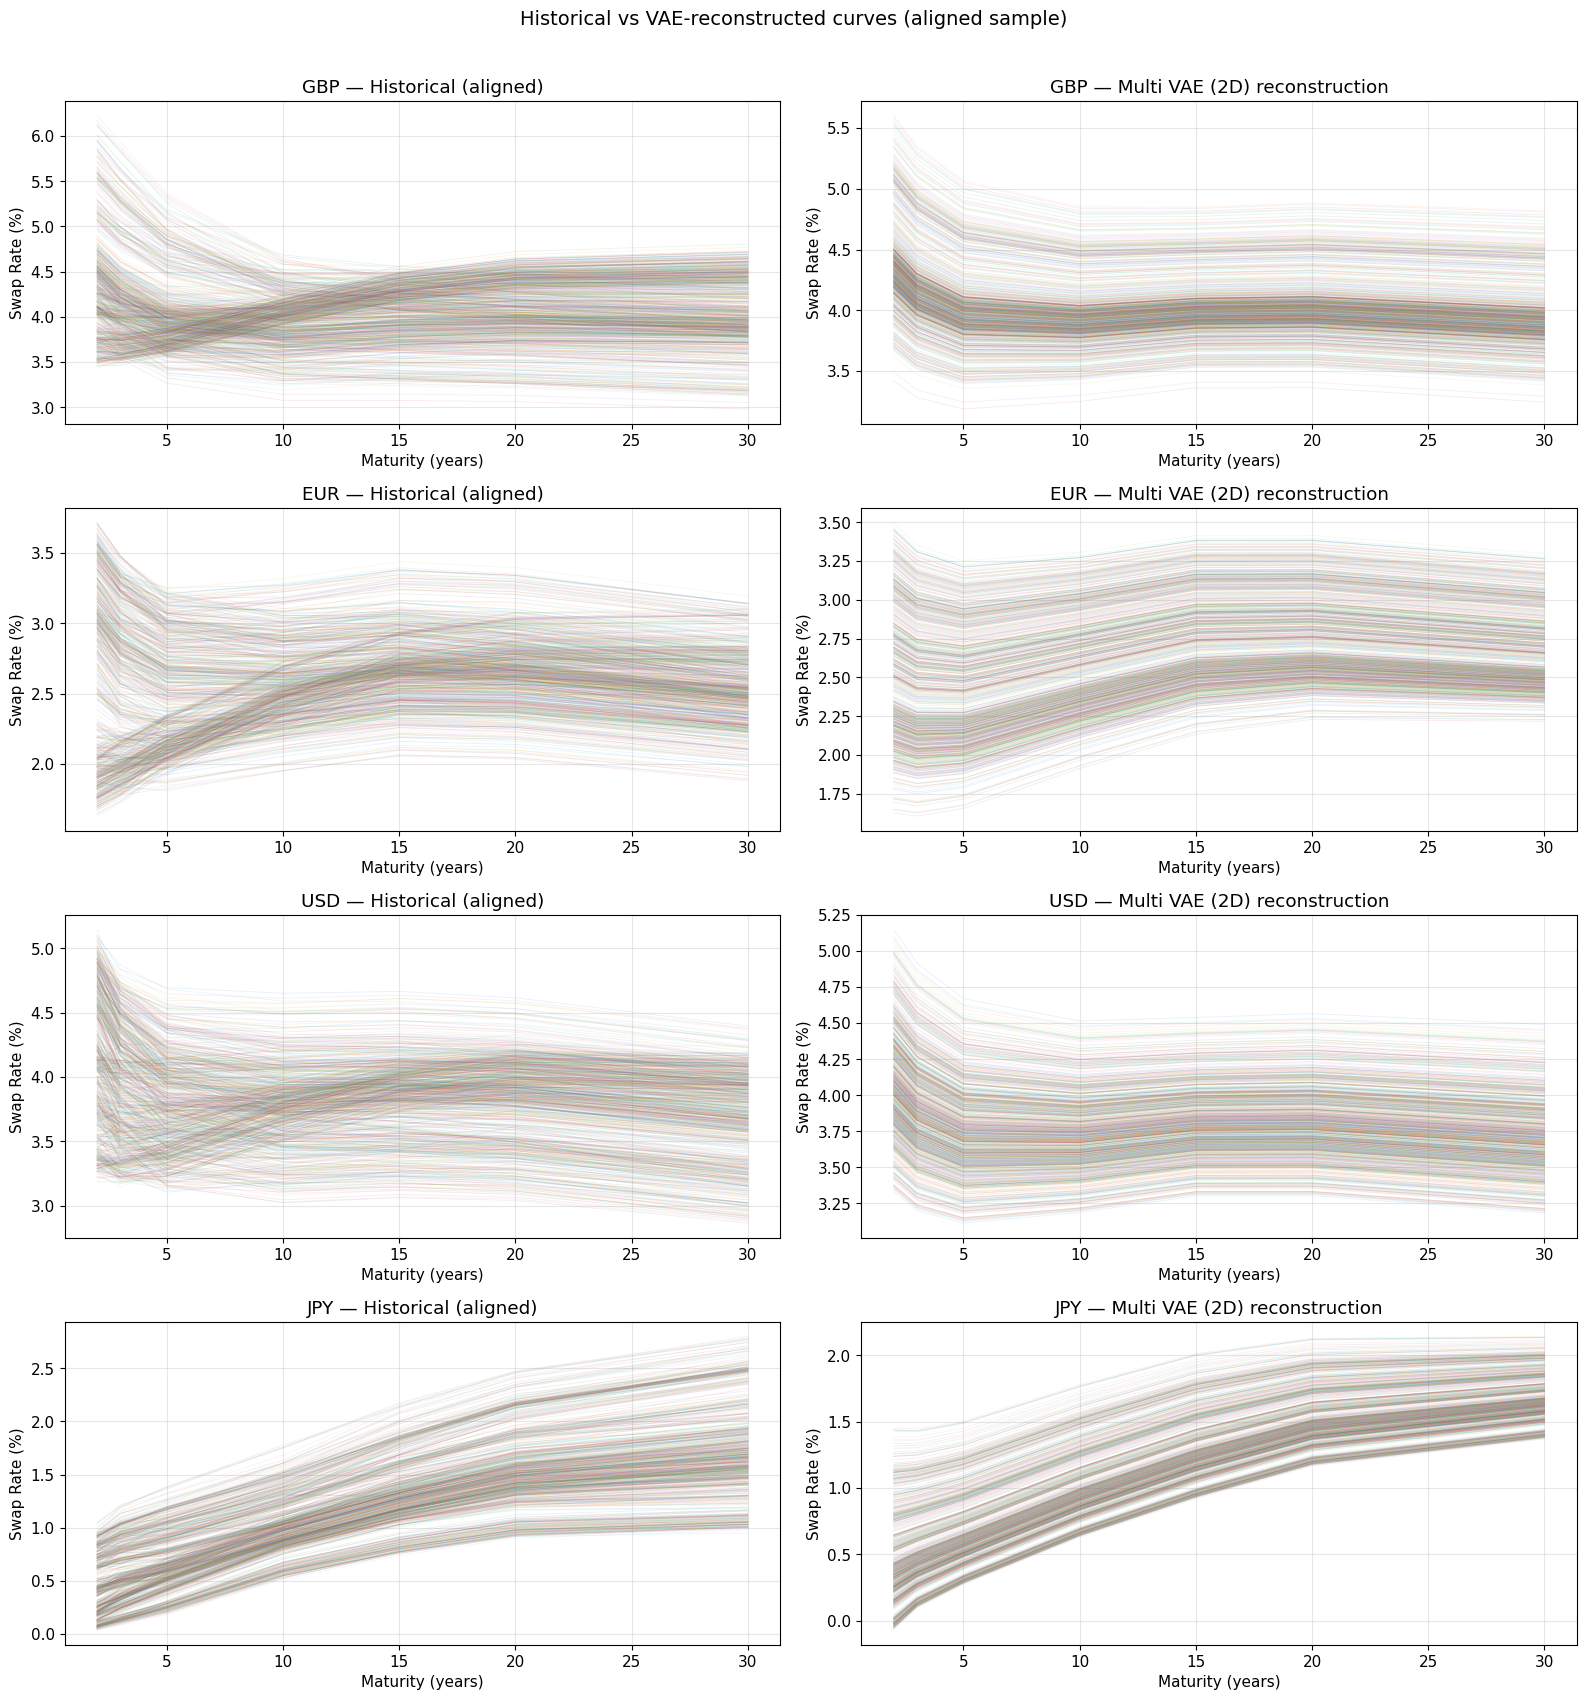

In [31]:
tenors = np.array(TARGET_TENORS, dtype=float)
fig, axes = plt.subplots(len(CURRENCIES), 2, figsize=(16, 4.2 * len(CURRENCIES)), squeeze=False)

for row, ccy in enumerate(CURRENCIES):
    df = swap_aligned[ccy]  # aligned, same dates across currencies
    rates_dec = df.values.astype(np.float32)  # decimal
    rates_norm = normalize_rates(rates_dec).astype(np.float32)

    X = torch.from_numpy(rates_norm).to(device)
    with torch.no_grad():
        X_recon_norm, _, _ = multi_vae(X)
    recon_dec = denormalize_rates(X_recon_norm.cpu().numpy())

    # Left: historical
    axL = axes[row, 0]
    for i in range(0, len(df), 1):
        axL.plot(tenors, 100.0 * rates_dec[i], alpha=0.10, lw=0.6)
    axL.set_title(f"{ccy} — Historical (aligned)")
    axL.set_xlabel("Maturity (years)")
    axL.set_ylabel("Swap Rate (%)")

    # Right: reconstructed
    axR = axes[row, 1]
    for i in range(0, len(df), 1):
        axR.plot(tenors, 100.0 * recon_dec[i], alpha=0.10, lw=0.6)
    axR.set_title(f"{ccy} — Multi VAE (2D) reconstruction")
    axR.set_xlabel("Maturity (years)")
    axR.set_ylabel("Swap Rate (%)")

plt.suptitle("Historical vs VAE-reconstructed curves (aligned sample)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("figs/fig_14_hist_vs_recon.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Out-of-sample analysis

Split data: train on first 70%, test on last 30%.

In [32]:
def vae_loss(x_recon, x, mu, logvar, beta=1e-7, N=7):
    recon = torch.mean((x_recon - x) ** 2, dim=-1).mean() / N
    kld = (-0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar), dim=-1)).mean()
    return recon + beta * kld, recon, kld

def train_vae_simple(model: nn.Module, X_train: torch.Tensor, n_epochs=2000, lr=1e-3, beta=1e-7):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True, drop_last=False)

    for epoch in range(n_epochs):
        for (xb,) in loader:
            xb = xb.to(device)
            x_recon, mu, logvar = model(xb)
            loss, _, _ = vae_loss(x_recon, xb, mu, logvar, beta=beta)
            opt.zero_grad()
            loss.backward()
            opt.step()

    model.eval()

def rmse_bp_array(model: nn.Module, X_norm: torch.Tensor) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        X_dev = X_norm.to(device)
        X_recon, _, _ = model(X_dev)

    recon_dec = denormalize_rates(X_recon.cpu().numpy())
    true_dec  = denormalize_rates(X_norm.cpu().numpy())
    rmse_bp = np.sqrt(np.mean((recon_dec - true_dec) ** 2, axis=1)) * BP_PER_UNIT
    return rmse_bp

In [33]:
# Build time-ordered split, within each currency then pool
SPLIT_RATIO = 0.70
X_train_parts, X_test_parts = [], []

for ccy in CURRENCIES:
    df = swap_aligned[ccy].sort_index()
    rates_norm = normalize_rates(df.values.astype(np.float32)).astype(np.float32)
    n = len(rates_norm)
    n_train = int(np.floor(n * SPLIT_RATIO))
    X_train_parts.append(torch.from_numpy(rates_norm[:n_train]))
    X_test_parts.append(torch.from_numpy(rates_norm[n_train:]))

X_train_oos = torch.cat(X_train_parts, dim=0).to(device)
X_test_oos  = torch.cat(X_test_parts, dim=0).to(device)

print(f"\nOOS split:")
print(f"  Train: {X_train_oos.shape[0]} samples")
print(f"  Test : {X_test_oos.shape[0]} samples")


OOS split:
  Train: 1992 samples
  Test : 856 samples


In [34]:
vae_oos = VAE(7, 2, 4, multi_currency=True).to(device)
print("Training OOS VAE (fresh model)")
train_vae_simple(vae_oos, X_train_oos, n_epochs=2000, lr=1e-3, beta=float(cfg["beta"]))

rmse_in = rmse_bp_array(vae_oos, X_train_oos)
rmse_out = rmse_bp_array(vae_oos, X_test_oos)

Training OOS VAE (fresh model)...


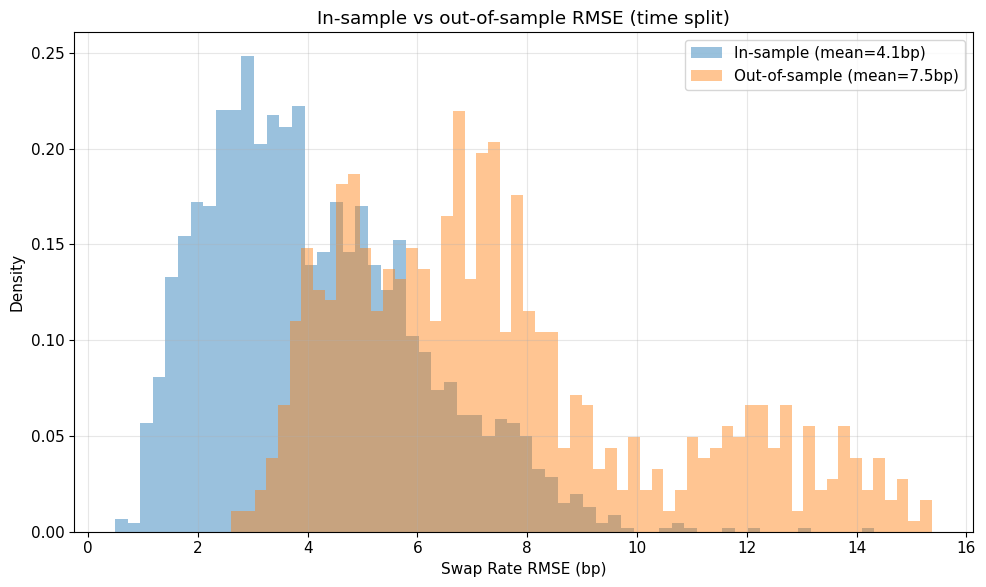

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(rmse_in, bins=60, alpha=0.45, density=True, label=f"In-sample (mean={rmse_in.mean():.1f}bp)")
ax.hist(rmse_out, bins=60, alpha=0.45, density=True, label=f"Out-of-sample (mean={rmse_out.mean():.1f}bp)")
ax.set_xlabel("Swap Rate RMSE (bp)")
ax.set_ylabel("Density")
ax.set_title("In-sample vs out-of-sample RMSE (time split)")
ax.legend()
plt.tight_layout()
plt.savefig("figs/fig_15_oos_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
print(f"In-sample  mean RMSE: {rmse_in.mean():.2f} bp")
print(f"Out-of-sample mean RMSE: {rmse_out.mean():.2f} bp")
print(f"Ratio OOS/IS: {rmse_out.mean()/rmse_in.mean():.2f}x")

In-sample  mean RMSE: 4.13 bp
Out-of-sample mean RMSE: 7.48 bp
Ratio OOS/IS: 1.81x


## 4.5 — Statistical test: VAE vs NS

In [37]:
# ── Wilcoxon signed-rank test on paired RMSE ────────────────────
print("Wilcoxon Signed-Rank Test: VAE(2D) vs NS(3D)")
print("H0: median RMSE difference = 0")
print("─" * 60)

for ccy in CURRENCIES:
    # NS/NSS lists are in the same order as swap_aligned[ccy] in notebook 2 if you fit on aligned df.
    # We assume that was the case. We still verify lengths.
    dates = swap_aligned[ccy].index
    ns_arr = rmse_ns.get(ccy, None)
    mvae_arr = np.asarray(rmse_vae.get(f"MultiVAE_{ccy}", None))
    cvae_arr = np.asarray(rmse_vae.get(f"CVAE_{ccy}", None))

    if ns_arr is None or mvae_arr is None or len(ns_arr) == 0 or len(mvae_arr) == 0:
        print(f"{ccy}: missing arrays, skipped.")
        continue

    n = min(len(ns_arr), len(mvae_arr), len(dates))
    ns_arr = ns_arr[:n]
    mvae_arr = mvae_arr[:n]

    # Wilcoxon requires not-all-zero diffs; handle edge case
    diff = ns_arr - mvae_arr
    if np.allclose(diff, 0.0):
        print(f"{ccy}: NS vs MultiVAE diffs all ~0, skipped.")
    else:
        stat, pval = stats.wilcoxon(ns_arr, mvae_arr)
        print(f"{ccy}  NS vs MultiVAE:  meanΔ={diff.mean():+.2f} bp   p={pval:.2e}   winner={'MultiVAE' if diff.mean()>0 else 'NS'}")

    # Optional: NS vs CVAE if present
    if cvae_arr is not None and len(cvae_arr):
        n2 = min(len(ns_arr), len(cvae_arr))
        ns2 = ns_arr[:n2]
        c2 = cvae_arr[:n2]
        diff2 = ns2 - c2
        if not np.allclose(diff2, 0.0):
            stat, pval = stats.wilcoxon(ns2, c2)
            print(f"{ccy}  NS vs CVAE:      meanΔ={diff2.mean():+.2f} bp   p={pval:.2e}   winner={'CVAE' if diff2.mean()>0 else 'NS'}")

Wilcoxon Signed-Rank Test: VAE(2D) vs NS(3D)
H0: median RMSE difference = 0
────────────────────────────────────────────────────────────
GBP  NS vs MultiVAE:  meanΔ=-22.52 bp   p=3.74e-118   winner=NS
GBP  NS vs CVAE:      meanΔ=-0.06 bp   p=2.08e-01   winner=NS
EUR  NS vs MultiVAE:  meanΔ=-12.58 bp   p=7.27e-116   winner=NS
EUR  NS vs CVAE:      meanΔ=+3.69 bp   p=2.28e-115   winner=CVAE
USD  NS vs MultiVAE:  meanΔ=-14.68 bp   p=2.92e-108   winner=NS
USD  NS vs CVAE:      meanΔ=+3.09 bp   p=2.43e-102   winner=CVAE
JPY  NS vs MultiVAE:  meanΔ=-5.83 bp   p=8.07e-91   winner=NS
JPY  NS vs CVAE:      meanΔ=+1.97 bp   p=5.38e-60   winner=CVAE


In [38]:
# Optional global test pooling currencies (still paired within each currency)
diff_pool = []
for ccy in CURRENCIES:
    ns_arr = rmse_ns.get(ccy, None)
    mvae_arr = np.asarray(rmse_vae.get(f"MultiVAE_{ccy}", None))
    if ns_arr is None or mvae_arr is None or len(ns_arr)==0 or len(mvae_arr)==0:
        continue
    n = min(len(ns_arr), len(mvae_arr))
    diff_pool.append((ns_arr[:n] - mvae_arr[:n]))
diff_pool = np.concatenate(diff_pool) if len(diff_pool) else np.array([])

if len(diff_pool):
    if not np.allclose(diff_pool, 0.0):
        stat, pval = stats.wilcoxon(diff_pool)
        print("\nPooled (all currencies):")
        print(f"  NS vs MultiVAE: meanΔ={diff_pool.mean():+.2f} bp   p={pval:.2e}   winner={'MultiVAE' if diff_pool.mean()>0 else 'NS'}")


Pooled (all currencies):
  NS vs MultiVAE: meanΔ=-13.90 bp   p=0.00e+00   winner=NS
